# Running autogen

* Autogen is a framework developed by Microsoft to create advanced LLM-based applications.
* It is designed to enable you to orchestrate multi-agent conversations that seamlessly integrate LLMs, human input and other tools.
* Autogen is supported by Microsoft, which gives it long term viability and was designed to specifically work with OpenAI, so it will be the framework we will be using in this class for agentic design.

To use autogen, we'll first need to install it in our virtual environment. We'll do so using pip.

## Ensure you are still in your virtual environment

If you are still in your virtual environment, you will see a `(.env)` at the beginning of your prompt terminal line.  
If not, you will need to reload your virtual environment, to do so on Windows, open a terminal in VSCode using :

If you're using the Command Prompt:  
`.env\Scripts\activate`

If you're using the PowerShell:  
`.env\Scripts\Activate.ps1`

And for Linux and MacOS:  
`source .env/Scripts/activate`

You should now see a `(.env)` at the beginning of your prompt terminal line.

## Install autogen

Before this, ensure that your python version is < 3.12
Ideally, you should install python 3.11

Installing autogen is quite simple, we'll simply use:

`pip install pyautogen==0.2.0`

You can then use autogen.

Let's use autogen to send a simple request to chatGPT, same as we did before, but through autogen this time. We're not making agents yet, just using autogen to prompt an LLM to ensure that we are able to use autogen.

First, let's import the modules we will need:

In [2]:
from autogen import ConversableAgent

/Users/jinhohyeon/Desktop/dev/Learned/llm/udemy-aiagents-building-teams-of-llm-agents/2/.venv/lib/python3.11/site-packages/flaml/__init__.py:20: UserWarning: flaml.automl is not available. Please install flaml[automl] to enable AutoML functionalities.
  warnings.warn("flaml.automl is not available. Please install flaml[automl] to enable AutoML functionalities.")


## Conversable Agent

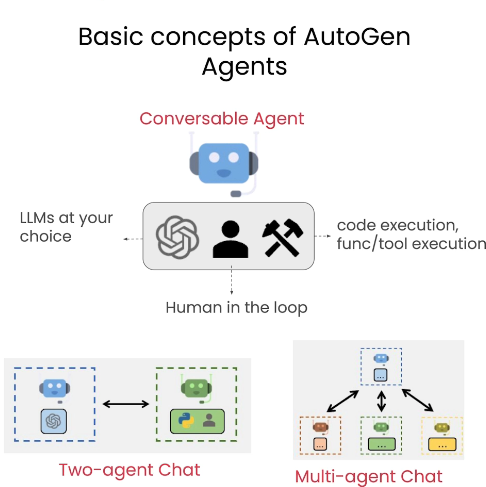

* AutoGen offers a unified multi-agent conversation framework that simplifies the orchestration and automation of complex LLM workflows the Conversable Agent class. These agents can collectively perform tasks autonomously or with human feedback.
* Conversable Agents are:
    * **Conversable**: Agents can send and receive messages from other agents or humans; thye can initate and continue a conversation seamlessly.
    * **Customizable**: They can be customized to integrate LLMs, human intervention, tools/skills (code) or combinations of these.
    * Of two subcategories:
        * **AssistantAgent**: This subcategory represents AI assistants, that use LLMs (such as GPT-4) by default. It can generate Python code for users to execute based on task descriptions. Additionally, it can receive execution results (from code or other agents) and suggest corrections or bug fixes.
        * **UserProxyAgent**:  This subcategory acts as a proxy agent for humans. It solicits human input as its reply during interactions. It also has the capability to execute code and call functions or tools. Code execution can be automatically triggered when an executable code block is detected in the received message.

Let's create a Conversable Agent to accomlpish a simple task. Before doing that, we will have to create a LLM config that specifies which LLM we want to use. Here we will again use chatGPT3.5 for now.

In [3]:
llm_config = {
    "model": "gpt-3.5-turbo", # From the list of models provided by OpenAI https://platform.openai.com/docs/models/continuous-model-upgrades
    }

We can now configure a Conversable Agent that will never ask for our input and will use chatGPT 3.5 to answer:

In [4]:
agent = ConversableAgent(
    name="chatbot",
    llm_config=llm_config, # The Agent will use the LLM config provided to answer
    human_input_mode="NEVER", # Can also be ALWAYS or TERMINATE (at end only)
)

Let's send a first request (a prompt) to this agent!  
We'll use the `generate_reply()` function of this agent, and we'll send it a message (we could actually send several) as a dictionary that must specify the `content` and the `role` keys. The `user` role means this is a request, we could use, as we did before, the `system` role to specify a system prompt for this agent (we'll re-do this later).

In [5]:
reply = agent.generate_reply(
    messages=[{"content": "Tell me a fun fact about money.", "role": "user"}]
)
print(reply)

A fun fact about money is that the average lifespan of a $1 bill is around 5.8 years, while a $100 bill can last up to 15 years. This is due to the higher denominations being used less frequently in transactions, resulting in less wear and tear.


Great! We're able to query this agent and get answers.  
Now the important point here is that when we use this `generate_reply()` function, we do not alter the state of this agent. This is not great if we want to have long conversations about a subject or solve tasks that require several steps. To explain what this means, if we try to ask this agent something that refers to this last query, we'll see that it has no idea what was this previous query...

In [6]:
reply = agent.generate_reply(
    messages=[{"content": "Repeat the fact.", "role": "user"}]
)
print(reply)

Sure, please provide me with the fact you would like me to repeat.


It always generates a new reply, a fresh one. But we need to keep the state to be able to solve complex tasks...
So we first need to be able to create conversations that alter the state of an agent if we want to solve complex tasks. 

So let's do this now by creating two agents that have evolving states based on their answers and that will converse based on these states.